# Operations & Logistics Turnaround Performance
**Objective**: Benchmark delivery times across Brazilian states and measure the empirical relationship between delivery delays and customer review scores.

C:\Users\Shubham Meena\AppData\Local\Temp\ipykernel_47196\2187265001.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_perf.head(10), x='customer_state', y='late_delivery_rate', palette='Reds_r')


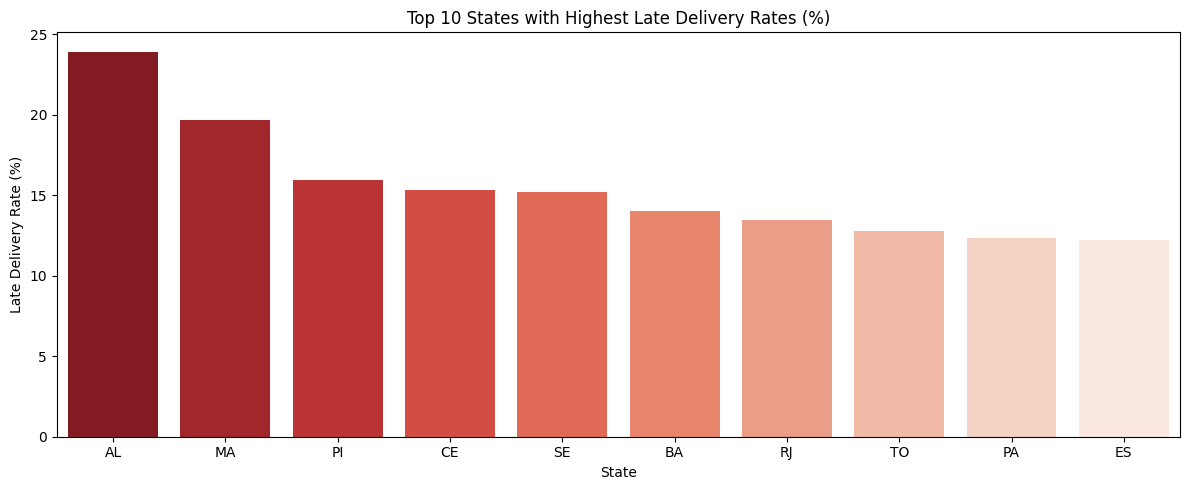

,customer_state,delivered_orders,avg_delivery_days,late_delivery_rate,avg_review
1,AL,397,24.543855,23.929471,3.852792
9,MA,717,21.572976,19.665272,3.833567
16,PI,476,19.457098,15.966387,3.993631
5,CE,1279,21.266579,15.324472,3.941870
24,SE,335,21.519788,15.223881,3.907186
4,BA,3256,19.335466,14.035627,3.930009
18,RJ,12350,15.309438,13.473684,3.965140
26,TO,274,17.658063,12.773723,4.153846
13,PA,946,23.772917,12.367865,3.909968
7,ES,1995,15.789307,12.230576,4.079736


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

proc_dir = r'../data/processed'
orders = pd.read_csv(os.path.join(proc_dir, 'clean_orders.csv'))
customers = pd.read_csv(os.path.join(proc_dir, 'clean_customers.csv'))

delivered = orders[orders['order_status'] == 'delivered'].merge(customers[['customer_id', 'customer_state']], on='customer_id')

state_perf = delivered.groupby('customer_state').agg(
    delivered_orders=('order_id', 'count'),
    avg_delivery_days=('actual_delivery_days', 'mean'),
    late_delivery_rate=('is_late', lambda x: x.mean() * 100),
    avg_review=('review_score', 'mean')
).reset_index().sort_values('late_delivery_rate', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=state_perf.head(10), x='customer_state', y='late_delivery_rate', palette='Reds_r')
plt.title('Top 10 States with Highest Late Delivery Rates (%)')
plt.ylabel('Late Delivery Rate (%)')
plt.xlabel('State')
plt.tight_layout()
plt.show()
state_perf.head(10)